Define regression datasets

In [1]:
# Set names for datasets
regression_datasets = ['fri_c3_1000_50',
 'fri_c2_1000_25',
 'fri_c4_500_50',
 'fri_c4_1000_50',
 'fri_c1_1000_25',
 'fri_c1_500_50',
 'fri_c3_1000_25',
 'auto93',
 'pyrim',
 'autoPrice',
 'boston',
 'Concrete_Compressive_Strength',
 'Auto_MPG',
 'Forest Fires',
 'Servo',
 'Airfoil_Self_Noise',
 'Wine_Quality',
 'BodyFat',
 'California_Housing',
 'Quake']

Inspect one dataset

In [1]:
import pickle

file_path = r"BASIC\Airfoil_Self_Noise_fold_data.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

print(type(data))   # to see what kind of object it is

<class 'dict'>


In [2]:
data['fold1']['Testing_Independent']

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness
15,0.021717,0.000000,1.000000,0.601010,0.041891
23,0.191919,0.000000,1.000000,0.601010,0.041891
29,0.000000,0.000000,1.000000,0.199495,0.046555
30,0.002525,0.000000,1.000000,0.199495,0.046555
32,0.010101,0.000000,1.000000,0.199495,0.046555
...,...,...,...,...,...
1471,0.242424,0.730769,0.272727,0.000000,0.714954
1473,0.000000,0.884615,0.272727,1.000000,0.746850
1481,0.053030,0.884615,0.272727,1.000000,0.746850
1493,0.030303,0.884615,0.272727,0.199495,0.904111


Build ML Models

In [13]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_models(folder_path):
    
    results = []

    # Define models
    models = {
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "DecisionTree": DecisionTreeRegressor(random_state=42),
        "KNN": KNeighborsRegressor(),
        "LinearRegression": LinearRegression(),
        "MLP": MLPRegressor(random_state=42),
        "RandomForest": RandomForestRegressor(random_state=42),
        "SVR": SVR()
    }

    # Loop through all files
    for filename in os.listdir(folder_path):
        if not filename.endswith(".pkl"):
            continue

        file_path = os.path.join(folder_path, filename)

        # Dataset name (remove suffix)
        dataset_name = filename.replace("_fold_data.pkl", "")

        # Load file
        with open(file_path, "rb") as f:
            data = pickle.load(f)

        # Loop models
        for model_name, model in models.items():

            nrmse_list = []
            nmae_list = []
            r2_list = []

            # Loop folds
            for fold in data.keys():

                fold_data = data[fold]

                X_train = fold_data['Training_Independent']
                y_train = fold_data['Training_Dependent']

                X_test = fold_data['Testing_Independent']
                y_test = fold_data['Testing_Dependent']

                # Fit
                model.fit(X_train, y_train)

                # Predict
                y_pred = model.predict(X_test)

                # Metrics
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                
                y_train_range = np.max(y_train) - np.min(y_train)

                nrmse = rmse / y_train_range
                nmae = mae / y_train_range

                # Store fold results
                nrmse_list.append(nrmse)
                nmae_list.append(nmae)
                r2_list.append(r2)

            # Average across folds
            results.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "NRMSE": np.mean(nrmse_list),
                "NMAE": np.mean(nmae_list),
                "R2": np.mean(r2_list)
            })

    # Convert to DataFrame
    df_results = pd.DataFrame(results)

    return df_results

In [15]:
df_orig = evaluate_models('BASIC')

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

In [17]:
df_bigfeat = evaluate_models('BIGFEAT')

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

In [18]:
df_openfe = evaluate_models('OPENFE')

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

In [19]:
df_safe = evaluate_models('SAFE')

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

In [20]:
df_autofeat = evaluate_models('AUTOFEAT')

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py

Evaluating HOFEES

In [38]:
def evaluate_maple_f(base_path):

    results = []

    # Map folder names → models
    model_map = {
        "AB": AdaBoostRegressor(random_state=42),
        "DT": DecisionTreeRegressor(random_state=42),
        "KNN": KNeighborsRegressor(),
        "Linear Regression": LinearRegression(),
        "MLP": MLPRegressor(random_state=42),
        "RF": RandomForestRegressor(random_state=42),
        "SVR": SVR()
    }

    for folder_name, model in model_map.items():

        folder_path = os.path.join(base_path, folder_name)

        for filename in os.listdir(folder_path):
            if not filename.endswith(".pkl"):
                continue

            file_path = os.path.join(folder_path, filename)

            dataset_name = filename.replace("_fold_data.pkl", "")

            with open(file_path, "rb") as f:
                data = pickle.load(f)

            nrmse_list, nmae_list, r2_list = [], [], []

            for fold in data.keys():

                fold_data = data[fold]

                X_train = fold_data['X_train_trans']
                y_train = fold_data['y_train'].values.ravel()

                X_test = fold_data['X_test_trans']
                y_test = fold_data['y_test'].values.ravel()

                # Fit ONLY the relevant model
                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)

                # Metrics
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                # Normalize by range
                y_range = np.max(y_train) - np.min(y_train)

                nrmse_list.append(rmse / y_range)
                nmae_list.append(mae / y_range)
                r2_list.append(r2)

            results.append({
                "Dataset": dataset_name,
                "Model": folder_name,
                "NRMSE": np.mean(nrmse_list),
                "NMAE": np.mean(nmae_list),
                "R2": np.mean(r2_list)
            })

    return pd.DataFrame(results)

In [39]:
df_maple = evaluate_maple_f("HOFEES")

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached 

Inspect one item

In [24]:
import pickle

file_path = r"HOFEES\AB\Airfoil_Self_Noise.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

print(type(data))  # optional: check what was loaded

<class 'dict'>


Rename HOFEES Columns

In [40]:
df_maple["Model"] = df_maple["Model"].replace({
    "AB": "AdaBoost",
    "DT": "DecisionTree",
    "KNN": "KNN",
    "Linear Regression": "LinearRegression",
    "MLP": "MLP",
    "RF": "RandomForest",
    "SVR": "SVR"
})

Rename all df columns

In [41]:
df_orig = df_orig.rename(columns={
    "NRMSE": "NRMSE_Original",
    "NMAE": "NMAE_Original",
    "R2": "R2_Original"
})

df_autofeat = df_autofeat.rename(columns={
    "NRMSE": "NRMSE_AutoFeat",
    "NMAE": "NMAE_AutoFeat",
    "R2": "R2_AutoFeat"
})

df_bigfeat = df_bigfeat.rename(columns={
    "NRMSE": "NRMSE_BigFeat",
    "NMAE": "NMAE_BigFeat",
    "R2": "R2_BigFeat"
})

df_openfe = df_openfe.rename(columns={
    "NRMSE": "NRMSE_OpenFE",
    "NMAE": "NMAE_OpenFE",
    "R2": "R2_OpenFE"
})

df_safe = df_safe.rename(columns={
    "NRMSE": "NRMSE_SAFE",
    "NMAE": "NMAE_SAFE",
    "R2": "R2_SAFE"
})

df_maple = df_maple.rename(columns={
    "NRMSE": "NRMSE_MAPLE_F",
    "NMAE": "NMAE_MAPLE_F",
    "R2": "R2_MAPLE_F"
})

Clean the dataframe name

In [46]:
for df in [df_orig, df_autofeat, df_bigfeat, df_openfe, df_safe, df_maple]:
    df["Dataset"] = df["Dataset"].str.replace(".pkl", "", regex=False)

Merge all dataframes

In [47]:
df_final = df_orig.copy()

df_final = df_final.merge(df_autofeat, on=["Dataset", "Model"], how="left")
df_final = df_final.merge(df_bigfeat, on=["Dataset", "Model"], how="left")
df_final = df_final.merge(df_openfe, on=["Dataset", "Model"], how="left")
df_final = df_final.merge(df_safe, on=["Dataset", "Model"], how="left")
df_final = df_final.merge(df_maple, on=["Dataset", "Model"], how="left")

In [49]:
df_final

,Dataset,Model,NRMSE_Original,NMAE_Original,R2_Original,NRMSE_AutoFeat,NMAE_AutoFeat,R2_AutoFeat,NRMSE_BigFeat,NMAE_BigFeat,R2_BigFeat,NRMSE_OpenFE,NMAE_OpenFE,R2_OpenFE,NRMSE_SAFE,NMAE_SAFE,R2_SAFE,NRMSE_MAPLE_F,NMAE_MAPLE_F,R2_MAPLE_F
0,Airfoil_Self_Noise,AdaBoost,0.104056,0.085049,0.682008,0.083480,0.066585,0.794407,0.090656,0.072085,0.756706,NaN,NaN,NaN,0.167454,0.135686,0.177992,0.086488,0.066985,0.779749
1,Airfoil_Self_Noise,DecisionTree,0.071319,0.051077,0.849164,0.071766,0.051236,0.848765,0.071973,0.050236,0.847069,NaN,NaN,NaN,0.102695,0.067293,0.689136,0.070238,0.050440,0.854689
2,Airfoil_Self_Noise,KNN,0.095948,0.073619,0.726350,0.071124,0.054570,0.849966,0.087892,0.067218,0.773176,NaN,NaN,NaN,0.137703,0.096951,0.432977,0.091651,0.069778,0.750354
3,Airfoil_Self_Noise,LinearRegression,0.130121,0.101412,0.501237,0.074258,0.055461,0.836439,0.116265,0.089324,0.603833,NaN,NaN,NaN,0.125210,0.096652,0.538493,0.110420,0.086096,0.639592
4,Airfoil_Self_Noise,MLP,0.695020,0.558921,-13.134656,0.375323,0.299316,-3.223185,0.694758,0.549066,-13.341270,NaN,NaN,NaN,0.492678,0.360043,-6.155127,0.828321,0.725314,-19.259368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Wine_Quality,KNN,0.117851,0.087989,0.343572,0.116037,0.086948,0.363779,0.118097,0.088307,0.340994,0.120432,0.090770,0.314707,0.136176,0.106660,0.123122,0.127864,0.096947,0.227728
136,Wine_Quality,LinearRegression,0.122734,0.094922,0.288204,0.119041,0.092259,0.330106,0.122296,0.094525,0.293250,0.408044,0.102249,-22.479584,0.124461,0.099022,0.268188,0.122526,0.094706,0.290615
137,Wine_Quality,MLP,0.119231,0.092662,0.328430,0.118103,0.091234,0.340628,0.120207,0.093263,0.317299,0.118815,0.092196,0.333106,0.122222,0.096590,0.294268,0.122448,0.094785,0.290907
138,Wine_Quality,RandomForest,0.101279,0.072198,0.515282,0.100171,0.071369,0.525859,0.101104,0.072306,0.517051,0.101582,0.072775,0.512415,0.122603,0.096644,0.289819,0.101109,0.072111,0.516919


Inspect NaN Count

In [52]:
nan_counts = {
    "R2_Original": df_final["R2_Original"].isna().sum(),
    "R2_AutoFeat": df_final["R2_AutoFeat"].isna().sum(),
    "R2_BigFeat": df_final["R2_BigFeat"].isna().sum(),
    "R2_OpenFE": df_final["R2_OpenFE"].isna().sum(),
    "R2_SAFE": df_final["R2_SAFE"].isna().sum(),
    "R2_MAPLE_F": df_final["R2_MAPLE_F"].isna().sum()
}

print(nan_counts)

{'R2_Original': np.int64(0), 'R2_AutoFeat': np.int64(7), 'R2_BigFeat': np.int64(14), 'R2_OpenFE': np.int64(14), 'R2_SAFE': np.int64(0), 'R2_MAPLE_F': np.int64(0)}


Build seperate dataframes for each metric

In [53]:
# R2 dataframe
df_r2 = df_final[[
    "Dataset", "Model",
    "R2_Original", "R2_AutoFeat", "R2_BigFeat",
    "R2_OpenFE", "R2_SAFE", "R2_MAPLE_F"
]]

# NMAE dataframe
df_nmae = df_final[[
    "Dataset", "Model",
    "NMAE_Original", "NMAE_AutoFeat", "NMAE_BigFeat",
    "NMAE_OpenFE", "NMAE_SAFE", "NMAE_MAPLE_F"
]]

# NRMSE dataframe
df_nrmse = df_final[[
    "Dataset", "Model",
    "NRMSE_Original", "NRMSE_AutoFeat", "NRMSE_BigFeat",
    "NRMSE_OpenFE", "NRMSE_SAFE", "NRMSE_MAPLE_F"
]]

In [54]:
df_r2

,Dataset,Model,R2_Original,R2_AutoFeat,R2_BigFeat,R2_OpenFE,R2_SAFE,R2_MAPLE_F
0,Airfoil_Self_Noise,AdaBoost,0.682008,0.794407,0.756706,NaN,0.177992,0.779749
1,Airfoil_Self_Noise,DecisionTree,0.849164,0.848765,0.847069,NaN,0.689136,0.854689
2,Airfoil_Self_Noise,KNN,0.726350,0.849966,0.773176,NaN,0.432977,0.750354
3,Airfoil_Self_Noise,LinearRegression,0.501237,0.836439,0.603833,NaN,0.538493,0.639592
4,Airfoil_Self_Noise,MLP,-13.134656,-3.223185,-13.341270,NaN,-6.155127,-19.259368
...,...,...,...,...,...,...,...,...
135,Wine_Quality,KNN,0.343572,0.363779,0.340994,0.314707,0.123122,0.227728
136,Wine_Quality,LinearRegression,0.288204,0.330106,0.293250,-22.479584,0.268188,0.290615
137,Wine_Quality,MLP,0.328430,0.340628,0.317299,0.333106,0.294268,0.290907
138,Wine_Quality,RandomForest,0.515282,0.525859,0.517051,0.512415,0.289819,0.516919


Conduct friedman test

In [23]:
from scipy.stats import friedmanchisquare
import pandas as pd

def friedman_test_per_model(df, metric_prefix):

    methods = [
        f"{metric_prefix}_Original",
        f"{metric_prefix}_AutoFeat",
        f"{metric_prefix}_BigFeat",
        f"{metric_prefix}_OpenFE",
        f"{metric_prefix}_SAFE",
        f"{metric_prefix}_MAPLE_F"
    ]

    rows = []

    for model in df["Model"].unique():
        df_model = df[df["Model"] == model]

        # Drop rows with NaNs
        df_model = df_model.dropna(subset=methods)

        samples = [df_model[m].values for m in methods]

        if len(df_model) > 1:
            stat, p = friedmanchisquare(*samples)
        else:
            stat, p = None, None

        rows.append({
            "Model": model,
            "Friedman_Statistic": stat,
            "p_value": p,
            "Significant (p<0.05)": p < 0.05 if p is not None else None
        })

    return pd.DataFrame(rows)

In [24]:
df_friedman_r2 = friedman_test_per_model(df_r2, "R2")
print(df_friedman_r2)

              Model  Friedman_Statistic       p_value  Significant (p<0.05)
0          AdaBoost           38.714286  2.710975e-07                  True
1      DecisionTree           15.464286  8.552243e-03                  True
2               KNN           25.286225  1.226747e-04                  True
3  LinearRegression           30.474061  1.189519e-05                  True
4               MLP           17.178571  4.173291e-03                  True
5      RandomForest           26.178571  8.239388e-05                  True
6               SVR            8.928571  1.119473e-01                 False


In [25]:
df_friedman_nrmse = friedman_test_per_model(df_nrmse, "NRMSE")
print(df_friedman_nrmse)

              Model  Friedman_Statistic       p_value  Significant (p<0.05)
0          AdaBoost           38.964286  2.414471e-07                  True
1      DecisionTree           18.035714  2.901976e-03                  True
2               KNN           23.318426  2.933820e-04                  True
3  LinearRegression           29.025045  2.292673e-05                  True
4               MLP           18.714286  2.172409e-03                  True
5      RandomForest           24.928571  1.438288e-04                  True
6               SVR            9.607143  8.716342e-02                 False


In [26]:
df_friedman_nmae = friedman_test_per_model(df_nmae, "NMAE")
print(df_friedman_nmae)

              Model  Friedman_Statistic       p_value  Significant (p<0.05)
0          AdaBoost           37.714286  4.306181e-07                  True
1      DecisionTree           21.142857  7.612286e-04                  True
2               KNN           24.266547  1.929440e-04                  True
3  LinearRegression           28.023256  3.601973e-05                  True
4               MLP           20.928571  8.356196e-04                  True
5      RandomForest           22.357143  4.477511e-04                  True
6               SVR           14.214286  1.430404e-02                  True


Export dataframe

In [89]:
df_nrmse.to_pickle("df_nrmse.pkl")
df_nmae.to_pickle("df_nmae.pkl")
df_r2.to_pickle("df_r2.pkl")

In [90]:
df_final.to_pickle("df_final.pkl")

Import the dataframes

In [1]:
import pandas as pd

df_nrmse = pd.read_pickle("df_nrmse.pkl")
df_nmae  = pd.read_pickle("df_nmae.pkl")
df_r2    = pd.read_pickle("df_r2.pkl")

Draw critical difference diagrams

In [4]:
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import pandas as pd

def plot_cd_from_wide(df, metric_prefix, name):

    methods = [
        f"{metric_prefix}_Original",
        f"{metric_prefix}_AutoFeat",
        f"{metric_prefix}_BigFeat",
        f"{metric_prefix}_OpenFE",
        f"{metric_prefix}_SAFE",
        f"{metric_prefix}_MAPLE_F"
    ]

    method_labels = ["Original", "AutoFeat", "BigFeat", "OpenFE", "SAFE", "MAPLE_F"]

    models = df["Model"].unique()

    # Subplot grid (adjust if needed)
    fig, axes = plt.subplots(4, 2, figsize=(20, 20))
    axes = axes.flatten()

    plt.rcParams.update({
        'font.size': 22,
        'axes.titlesize': 24,
        'axes.labelsize': 20
    })
    for i, model in enumerate(models):

        if i >= len(axes):
            break

        df_model = df[df["Model"] == model].dropna(subset=methods)

        if len(df_model) < 2:
            axes[i].axis('off')
            continue

        # Convert wide → long format
        df_long = df_model.melt(
            id_vars=["Dataset"],
            value_vars=methods,
            var_name="Method",
            value_name="Score"
        )

        # Clean method names
        df_long["Method"] = df_long["Method"].str.replace(f"{metric_prefix}_", "")

        # IMPORTANT: ranking direction
        ascending = True if metric_prefix != "R2" else False

        # Average ranks
        avg_rank = (
            df_long.groupby("Dataset")["Score"]
            .rank(ascending=ascending)
            .groupby(df_long["Method"])
            .mean()
        )

        # Nemenyi test
        nemenyi = sp.posthoc_nemenyi_friedman(
            df_long,
            melted=True,
            block_col="Dataset",
            group_col="Method",
            y_col="Score"
        )

        ax = axes[i]
        plt.sca(ax)

        sp.critical_difference_diagram(
            ranks=avg_rank,
            sig_matrix=nemenyi,
            label_fmt_left='{label} [{rank:.2f}]',
            label_fmt_right='[{rank:.2f}] {label}',
            text_h_margin=0.2,
            label_props={'fontsize': 10},
            ax=ax
        )

        for text in ax.texts:
            text.set_fontsize(18)   # increase as needed (20–24 for papers)
            text.set_fontweight('bold')

        ax.set_title(model)

    # Hide unused plots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'S

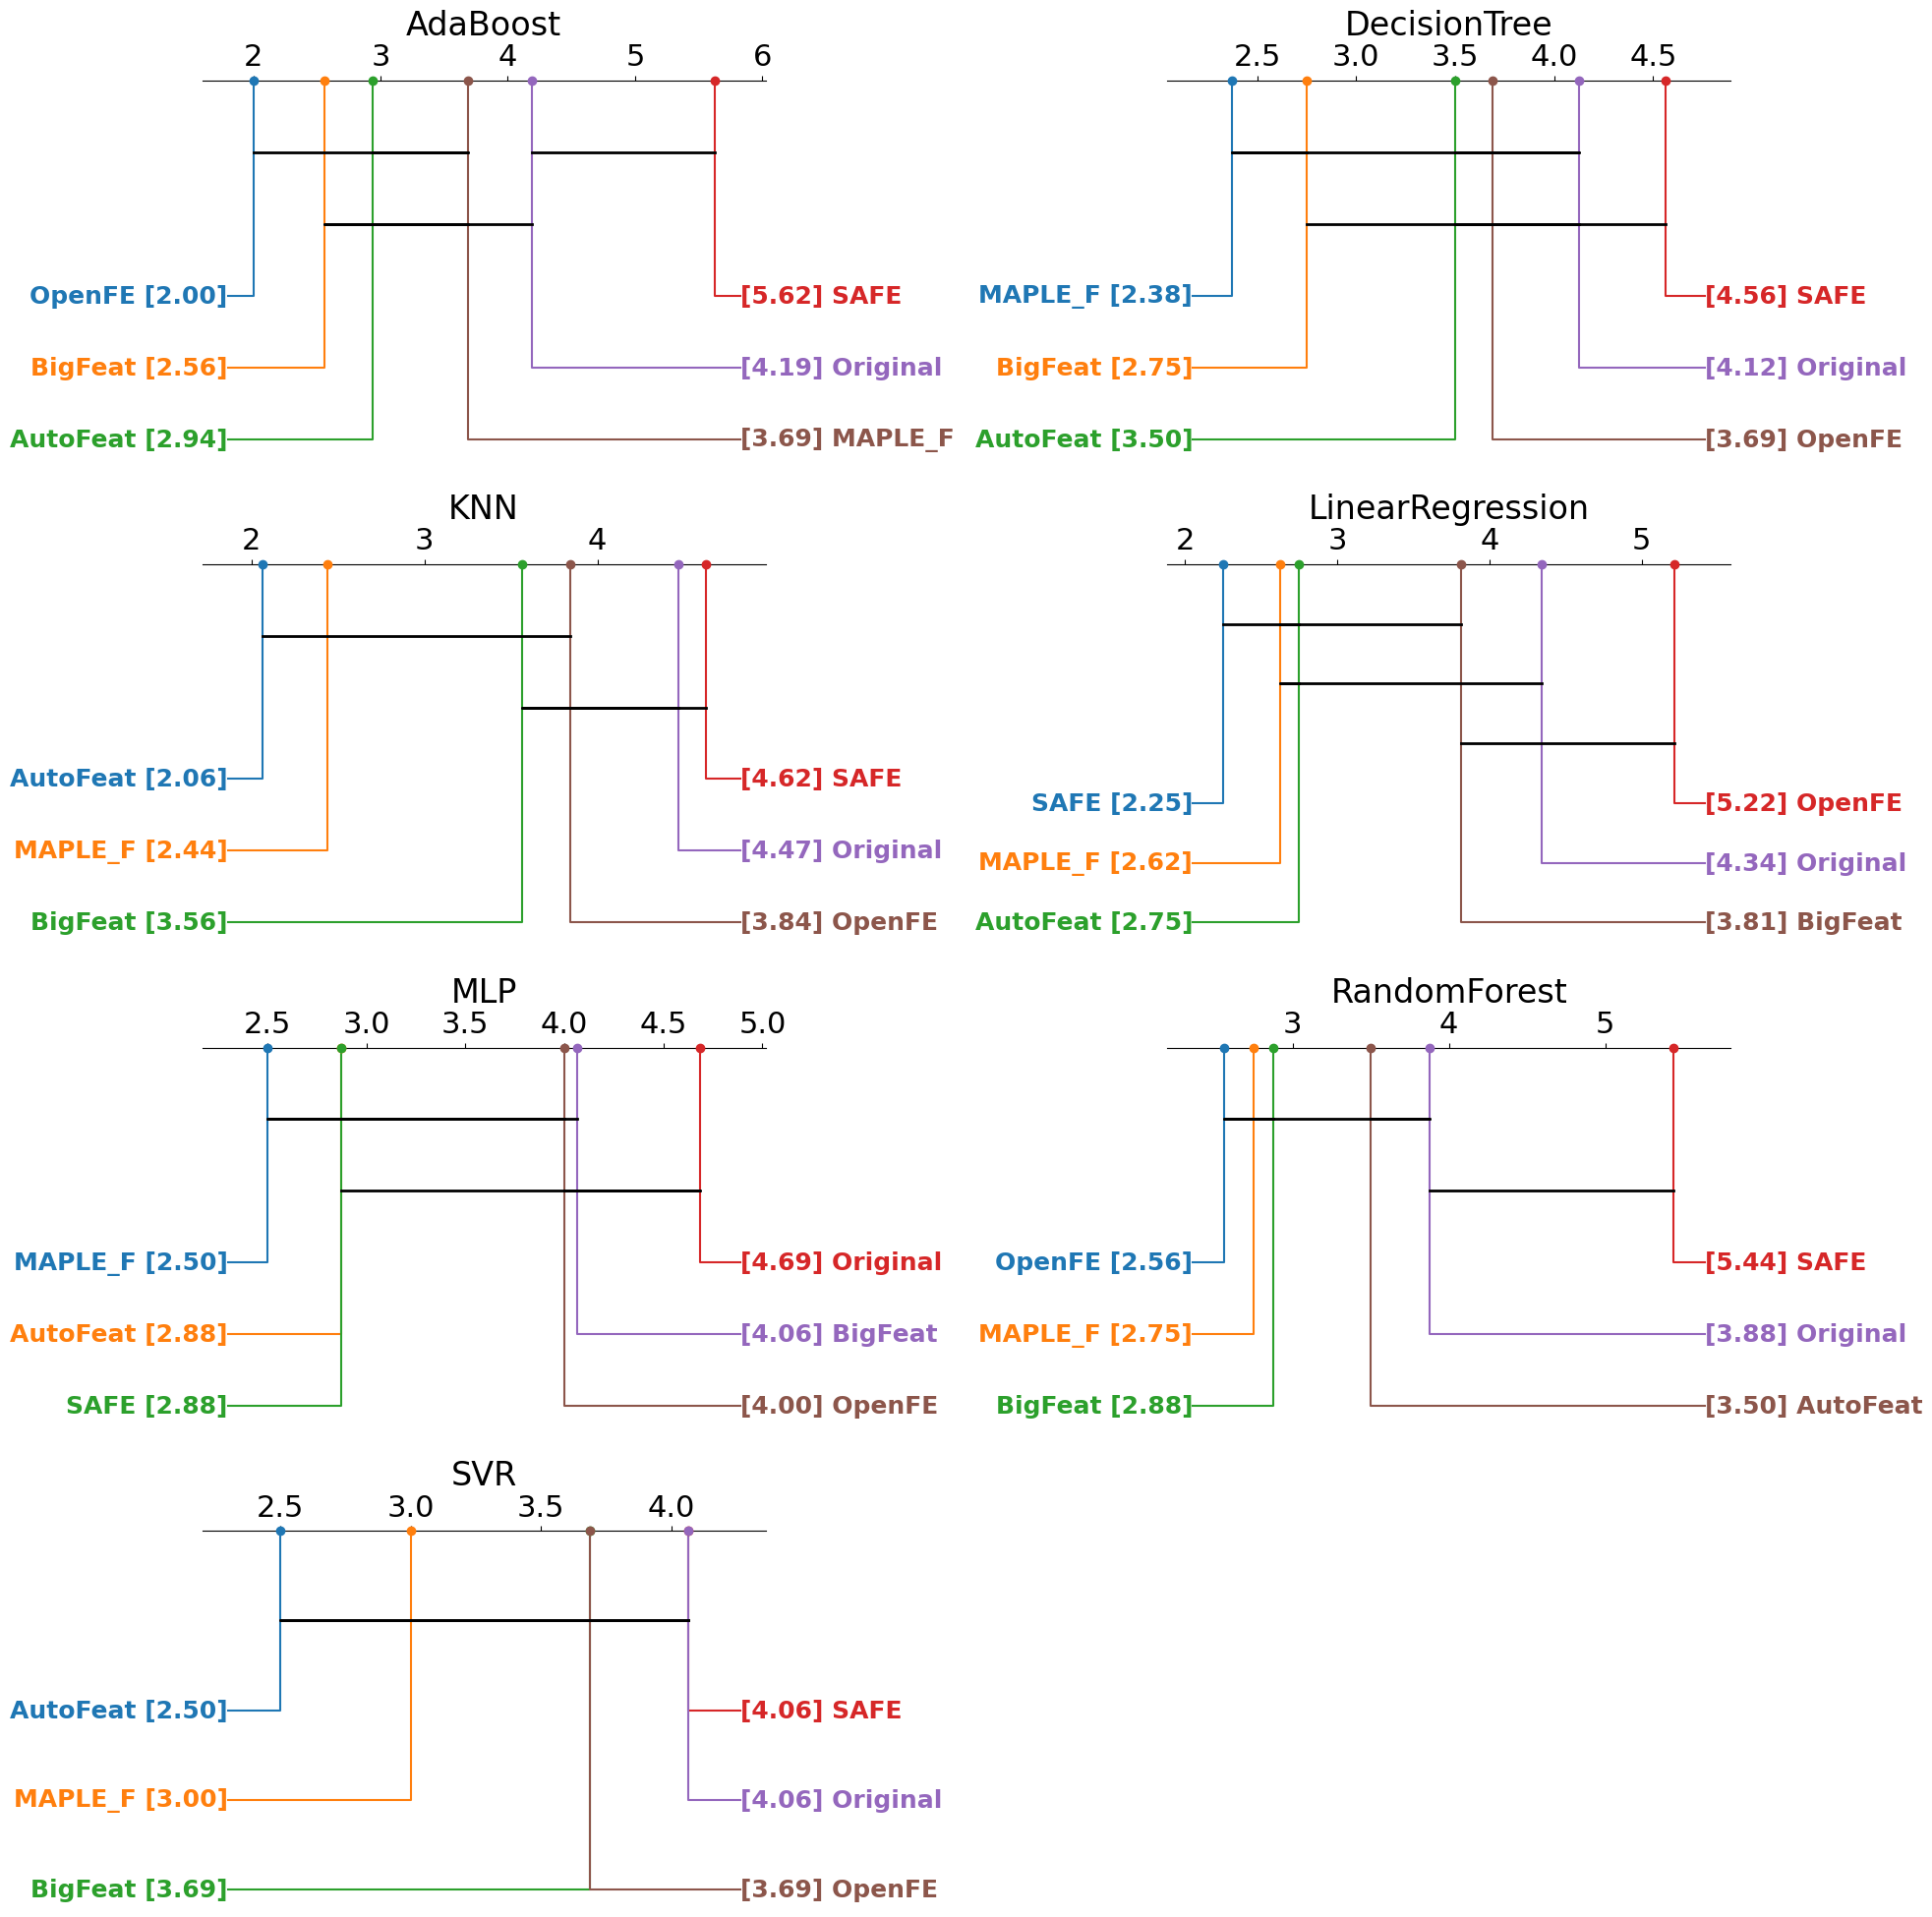

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'S

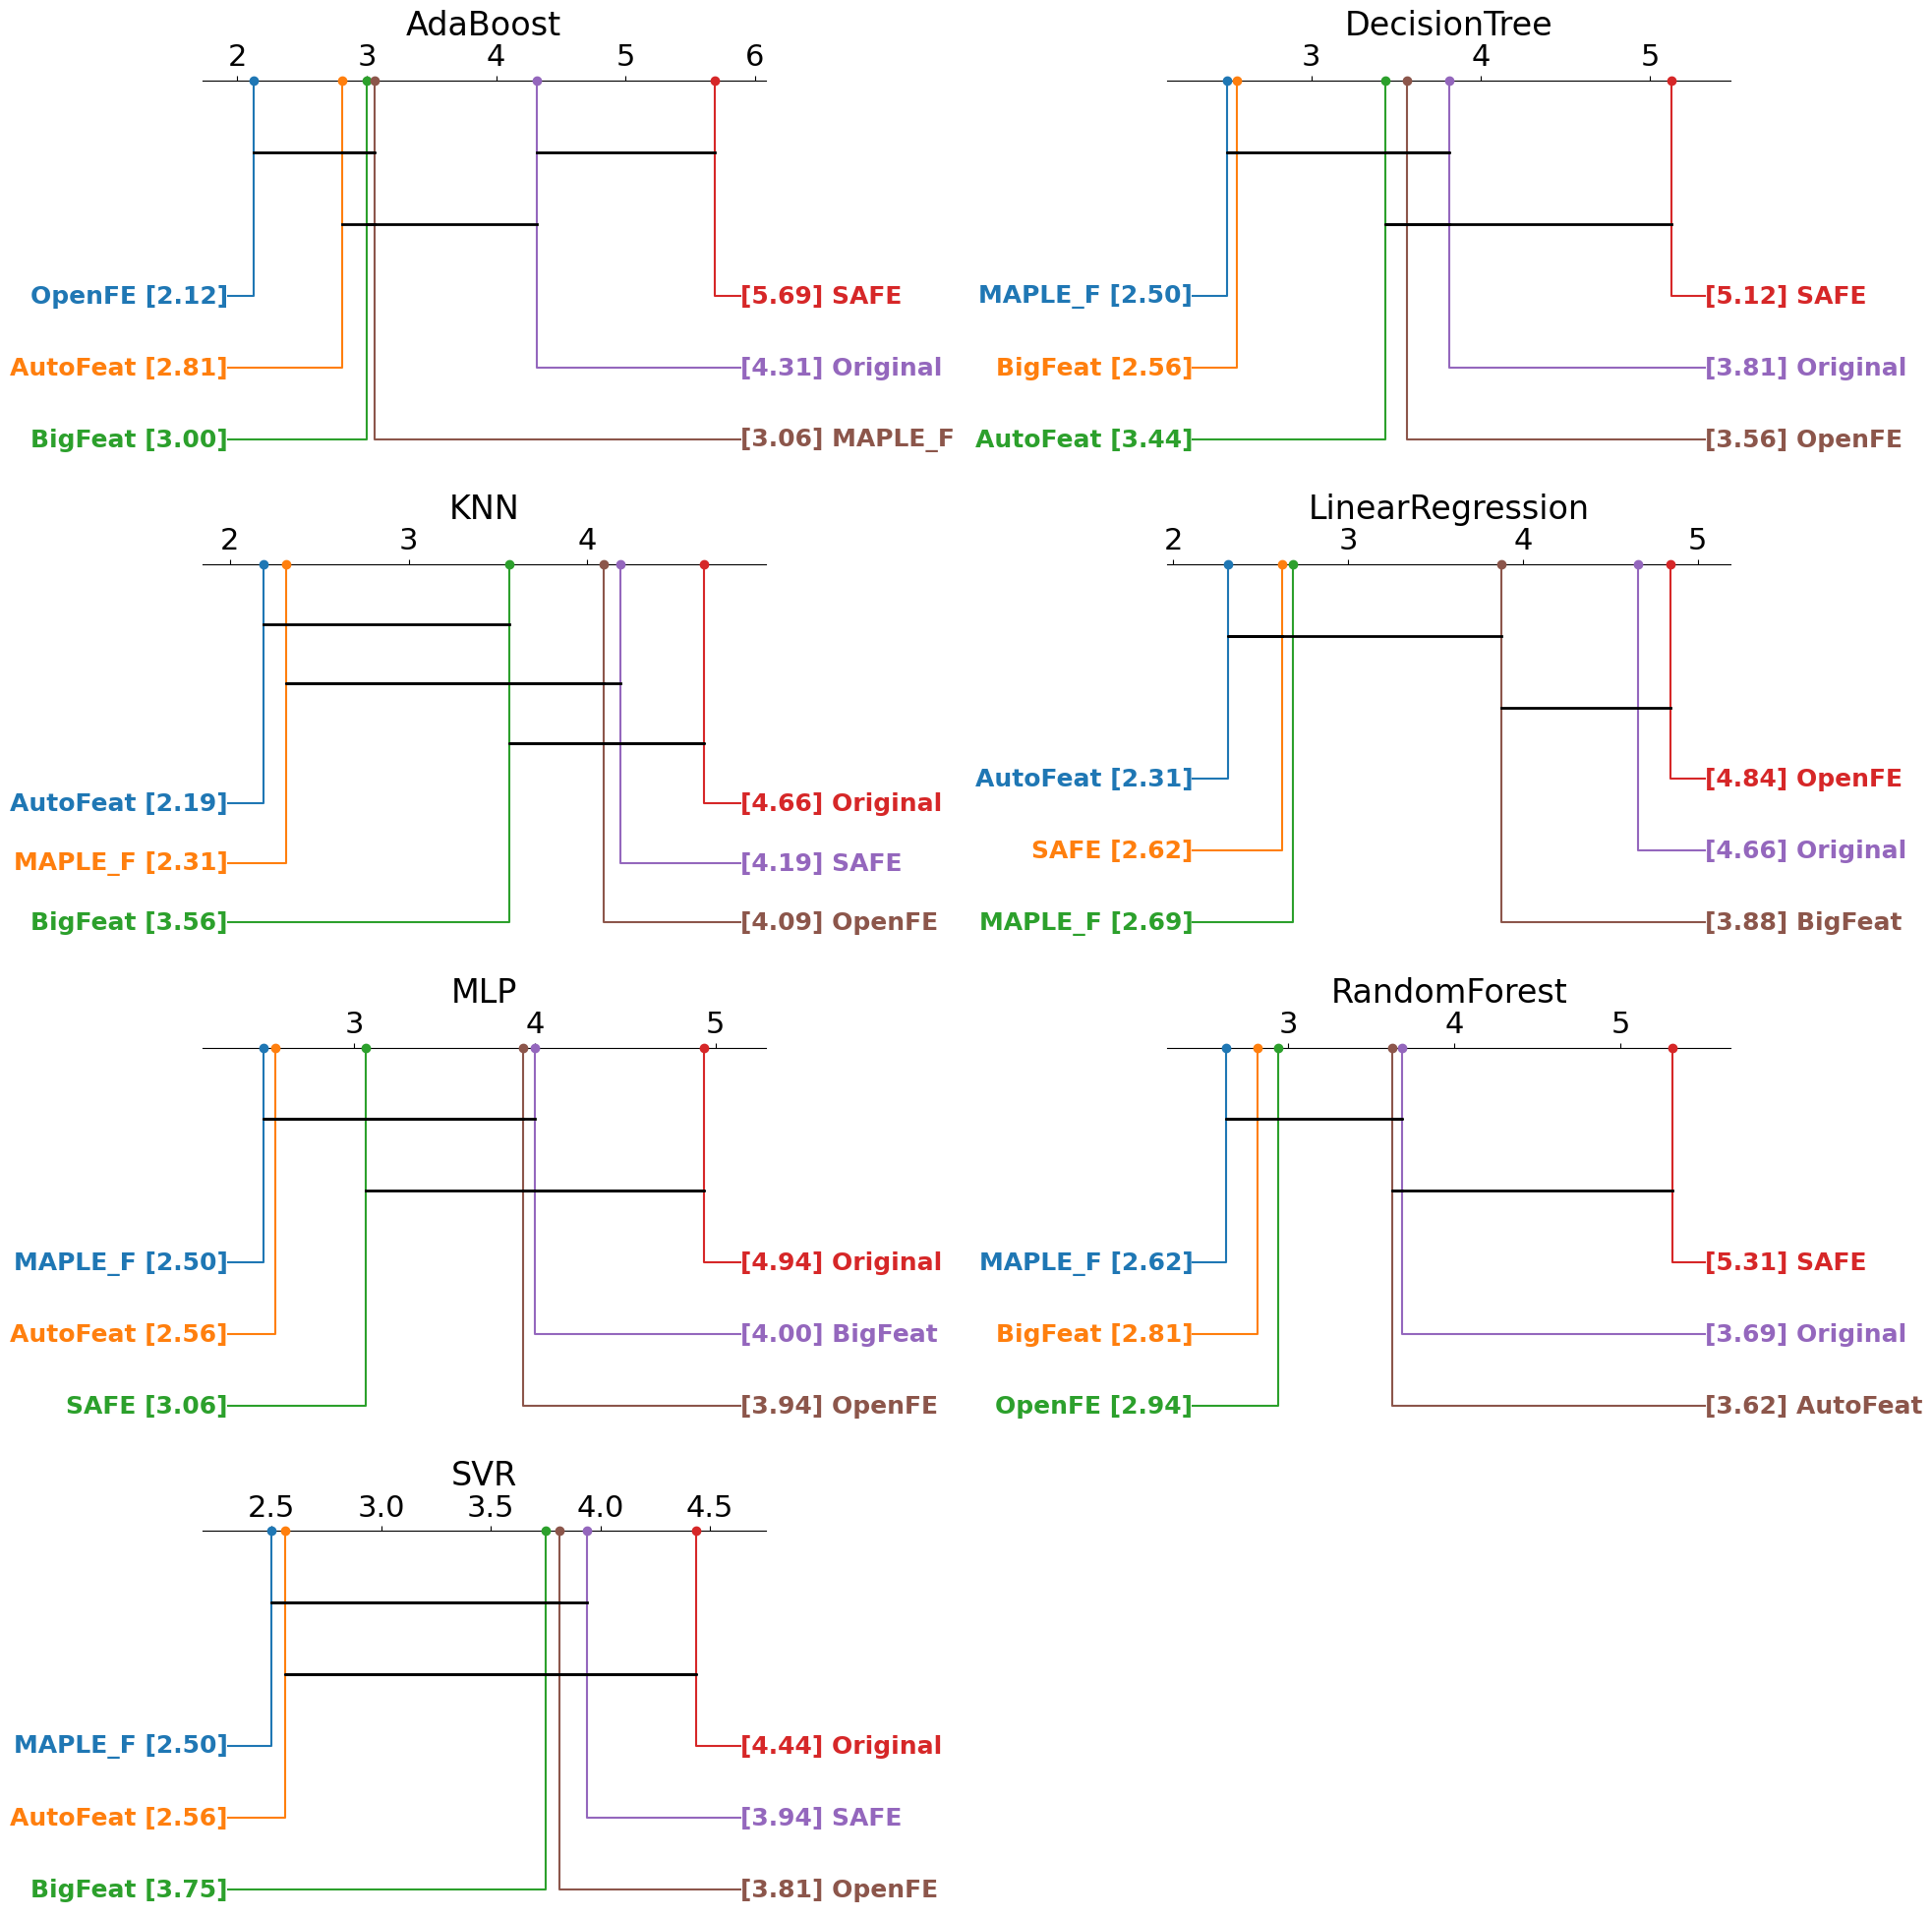

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'S

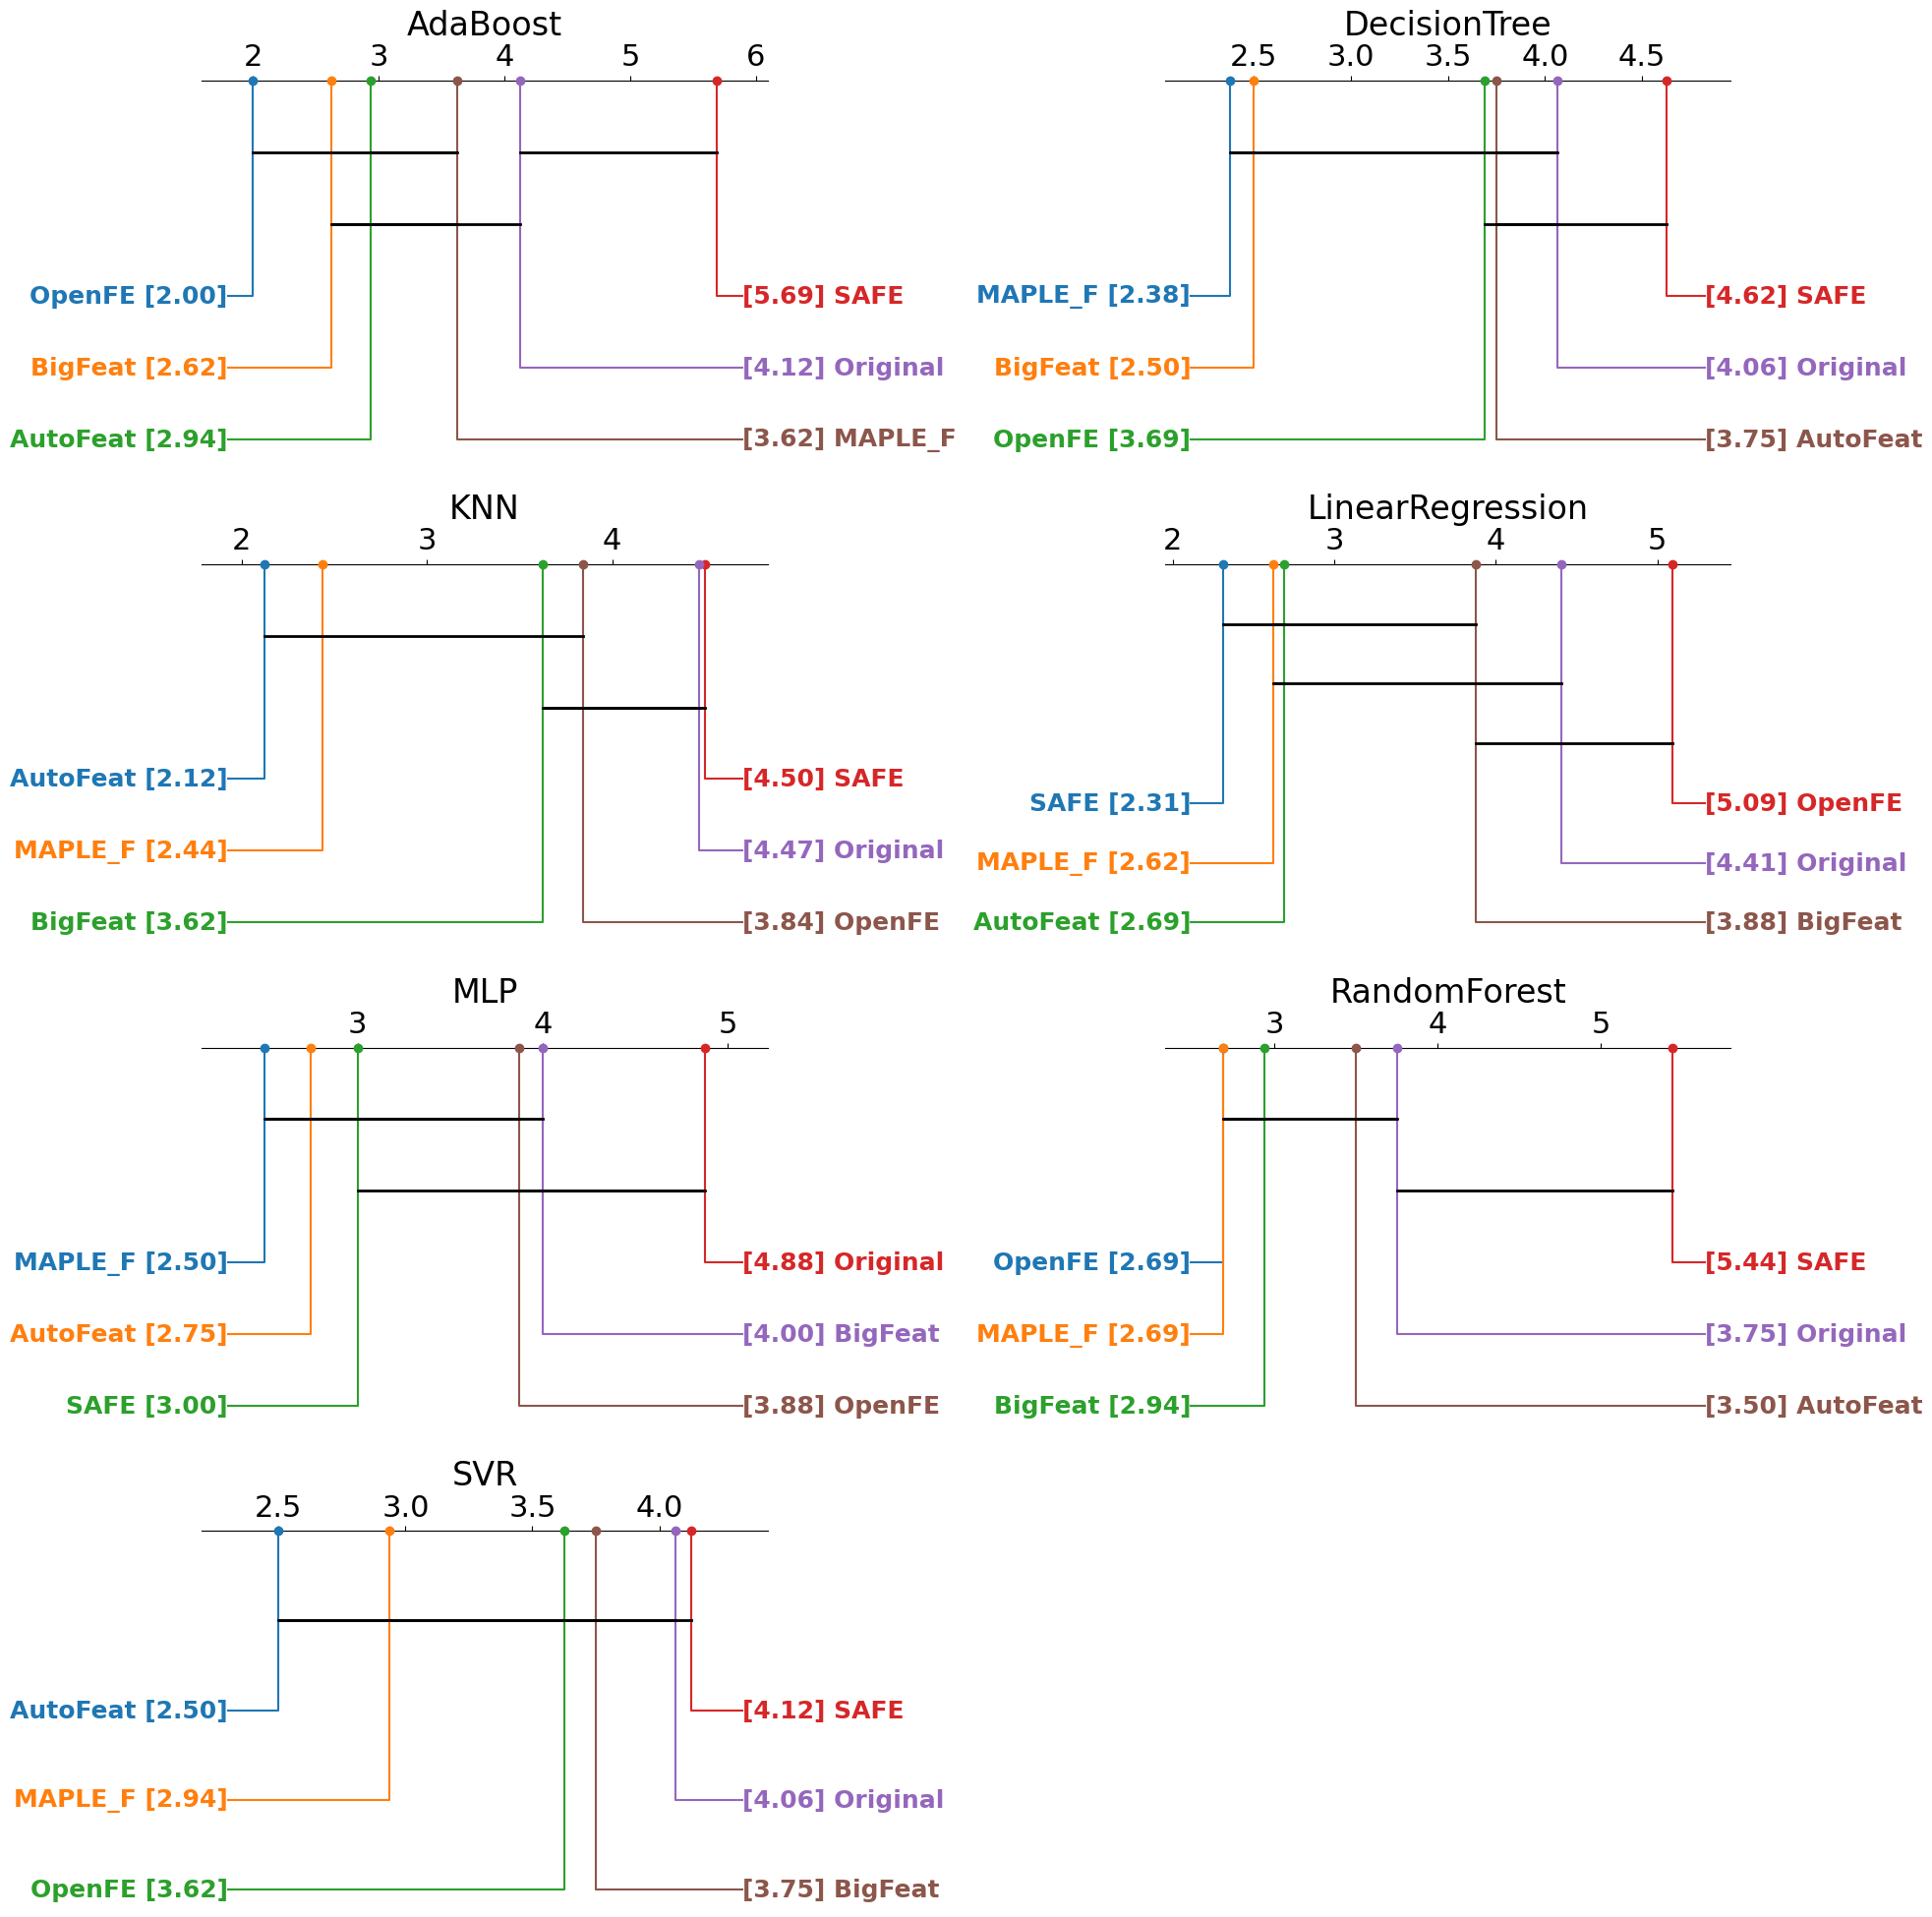

In [5]:
plot_cd_from_wide(df_r2, "R2", "R2_CD")
plot_cd_from_wide(df_nmae, "NMAE", "NMAE_CD")
plot_cd_from_wide(df_nrmse, "NRMSE", "NRMSE_CD")

Single Model

In [17]:
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import pandas as pd

def plot_cd_single(df, metric_prefix):

    methods = [
        f"{metric_prefix}_Original",
        f"{metric_prefix}_AutoFeat",
        f"{metric_prefix}_BigFeat",
        f"{metric_prefix}_OpenFE",
        f"{metric_prefix}_SAFE",
        f"{metric_prefix}_HOFEES"
    ]

    method_labels = ["Original", "AutoFeat", "BigFeat", "OpenFE", "SAFE", "MAPLE_F"]

    # Drop missing
    df_clean = df.dropna(subset=methods)

    if len(df_clean) < 2:
        print("Not enough data")
        return

    # Wide → long
    df_long = df_clean.melt(
        id_vars=["Dataset", "Model"],   # keep both (important!)
        value_vars=methods,
        var_name="Method",
        value_name="Score"
    )

    # Clean names
    df_long["Method"] = df_long["Method"].str.replace(f"{metric_prefix}_", "")

    # 🔥 KEY IDEA: treat (Dataset + Model) as ONE block
    df_long["Block"] = df_long["Dataset"] + "_" + df_long["Model"].astype(str)

    # Ranking direction
    ascending = True if metric_prefix != "R2" else False

    # Average ranks
    avg_rank = (
        df_long.groupby("Block")["Score"]
        .rank(ascending=ascending)
        .groupby(df_long["Method"])
        .mean()
    )

    # Nemenyi
    nemenyi = sp.posthoc_nemenyi_friedman(
        df_long,
        melted=True,
        block_col="Block",
        group_col="Method",
        y_col="Score"
    )


    # BIG FONT SETTINGS
    plt.rcParams.update({
        "font.size": 22,
        "axes.titlesize": 28,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20
    })

    # Plot
    fig = plt.figure(figsize=(16, 6))

    sp.critical_difference_diagram(
        ranks=avg_rank,
        sig_matrix=nemenyi,
        label_fmt_left='{label} [{rank:.2f}]',
        label_fmt_right='[{rank:.2f}] {label}',
        text_h_margin=0.2
    )

    # plt.title(f"Critical Difference Diagram ({metric_prefix})")


    # Save as PDF
    plt.savefig(f"CD_Diagram_{metric_prefix}.pdf",
                format="pdf",
                bbox_inches="tight")

    plt.show()

Rename the model

In [10]:
df_r2.rename(columns={"R2_MAPLE_F": "R2_HOFEES"}, inplace=True)

df_nmae.rename(columns={"NMAE_MAPLE_F": "NMAE_HOFEES"}, inplace=True)

df_nrmse.rename(columns={"NRMSE_MAPLE_F": "NRMSE_HOFEES"}, inplace=True)

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


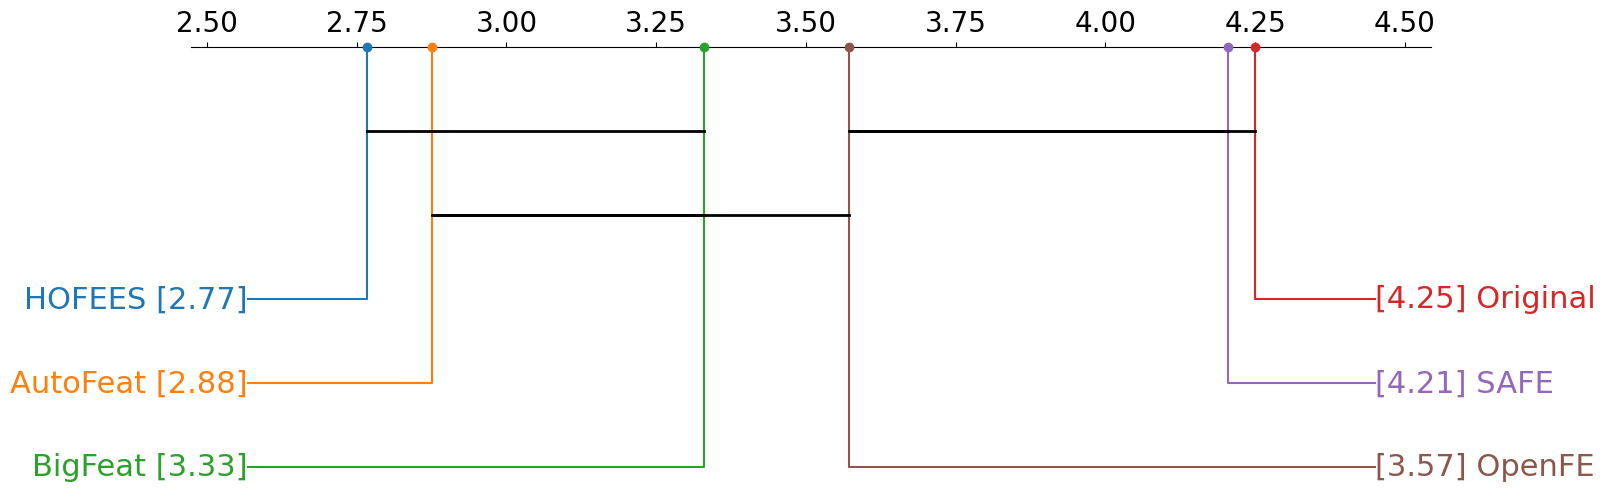

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


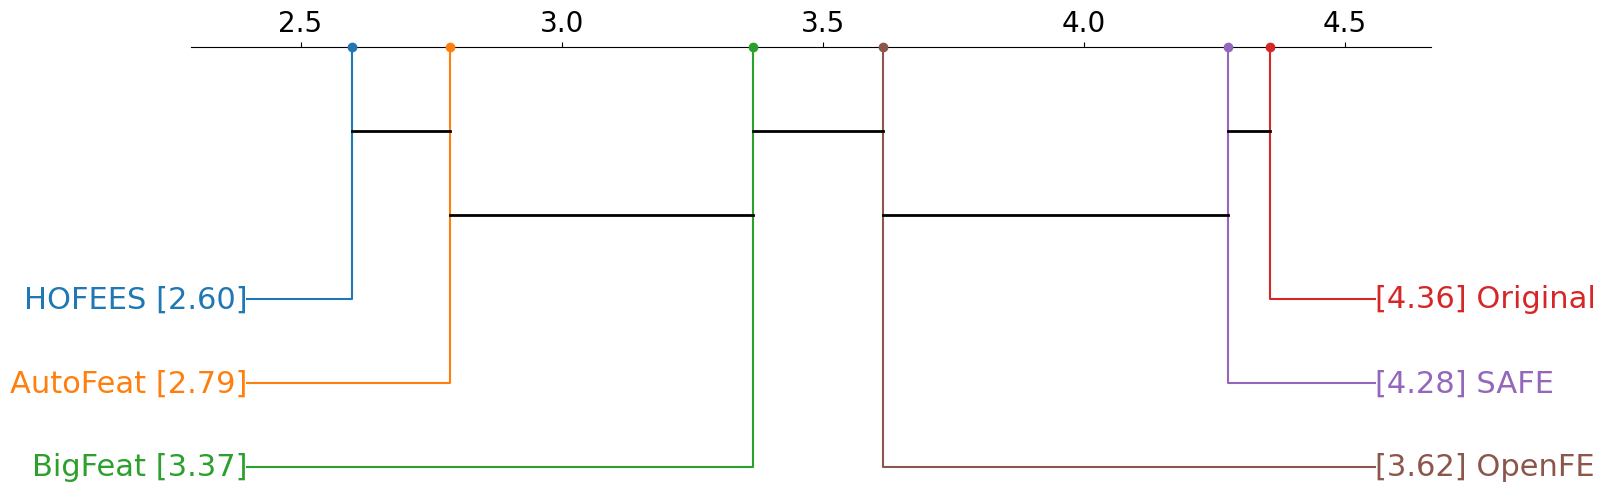

c:\Users\25644574\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


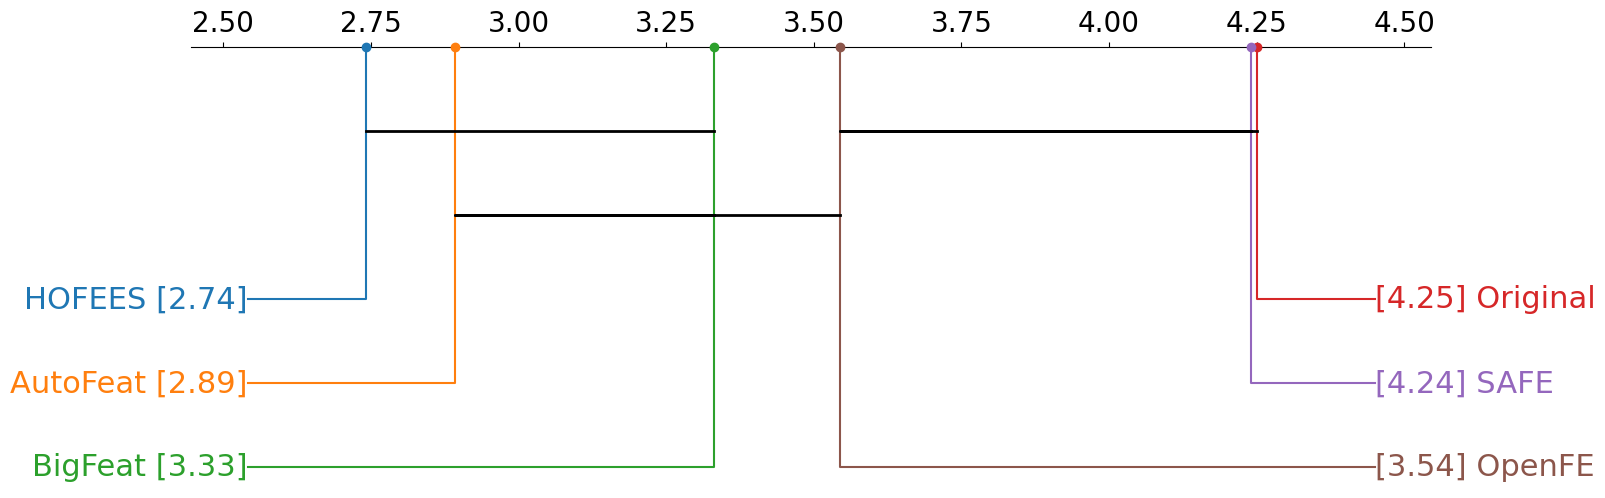

In [18]:
plot_cd_single(df_r2, "R2")
plot_cd_single(df_nmae, "NMAE")
plot_cd_single(df_nrmse, "NRMSE")